<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/05_correlation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'

TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']

datasets = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/features/{ticker}_features.csv')
    df['date'] = pd.to_datetime(df['date'])
    datasets[ticker] = df

print(f'✅ Загружено тикеров: {len(datasets)}')
for ticker, df in datasets.items():
    print(f'  {ticker}: {len(df)} строк, {df.shape[1]} признаков')

Mounted at /content/drive
✅ Загружено тикеров: 6
  MOEX: 533 строк, 55 признаков
  SBER: 533 строк, 55 признаков
  GAZP: 533 строк, 55 признаков
  LKOH: 533 строк, 55 признаков
  PLZL: 533 строк, 55 признаков
  YDEX: 506 строк, 55 признаков


In [2]:
# Признаки сентимента для анализа
SENTIMENT_FEATURES = [
    'sentiment_mean', 'sentiment_net', 'sentiment_mean_lag1',
    'sentiment_net_lag1', 'sentiment_mean_lag2', 'sentiment_net_lag2',
    'sentiment_mean_lag3', 'sentiment_net_lag3', 'sentiment_ma3',
    'sentiment_ma7', 'negative_ratio', 'positive_ratio',
    'negative_ratio_lag1', 'positive_ratio_lag1', 'sentiment_change1'
]

# Считаем корреляции Pearson и Spearman для каждого тикера
results = []

for ticker, df in datasets.items():
    for feature in SENTIMENT_FEATURES:
        # Pearson
        r_p, p_p = stats.pearsonr(df[feature].dropna(),
                                   df['return_1d'].loc[df[feature].dropna().index])
        # Spearman
        r_s, p_s = stats.spearmanr(df[feature].dropna(),
                                    df['return_1d'].loc[df[feature].dropna().index])
        results.append({
            'ticker': ticker,
            'feature': feature,
            'pearson_r': r_p,
            'pearson_p': p_p,
            'spearman_r': r_s,
            'spearman_p': p_s,
            'significant': p_p < 0.05
        })

df_corr = pd.DataFrame(results)

print('=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===')
sig = df_corr[df_corr['significant']].sort_values('pearson_r', ascending=False)
print(sig[['ticker', 'feature', 'pearson_r', 'pearson_p']].to_string(index=False))

=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===
ticker             feature  pearson_r  pearson_p
  PLZL      sentiment_mean   0.168934   0.000089
  PLZL       sentiment_net   0.168934   0.000089
  PLZL      positive_ratio   0.138876   0.001308
  YDEX       sentiment_net   0.122829   0.005664
  YDEX      sentiment_mean   0.122829   0.005664
  LKOH      sentiment_mean   0.120103   0.005497
  LKOH       sentiment_net   0.120103   0.005497
  LKOH   sentiment_change1   0.115662   0.007518
  SBER       sentiment_net   0.115332   0.007692
  SBER      sentiment_mean   0.115332   0.007692
  PLZL       sentiment_ma3   0.112425   0.009386
  MOEX      sentiment_mean   0.109794   0.011197
  MOEX       sentiment_net   0.109794   0.011197
  GAZP      positive_ratio   0.103369   0.016975
  SBER   sentiment_change1   0.101235   0.019403
  GAZP   sentiment_change1   0.099418   0.021702
  GAZP      sentiment_mean   0.096825   0.025391
  GAZP       sentiment_net   0.096825   0.025391
  LKOH      positive_ratio   0

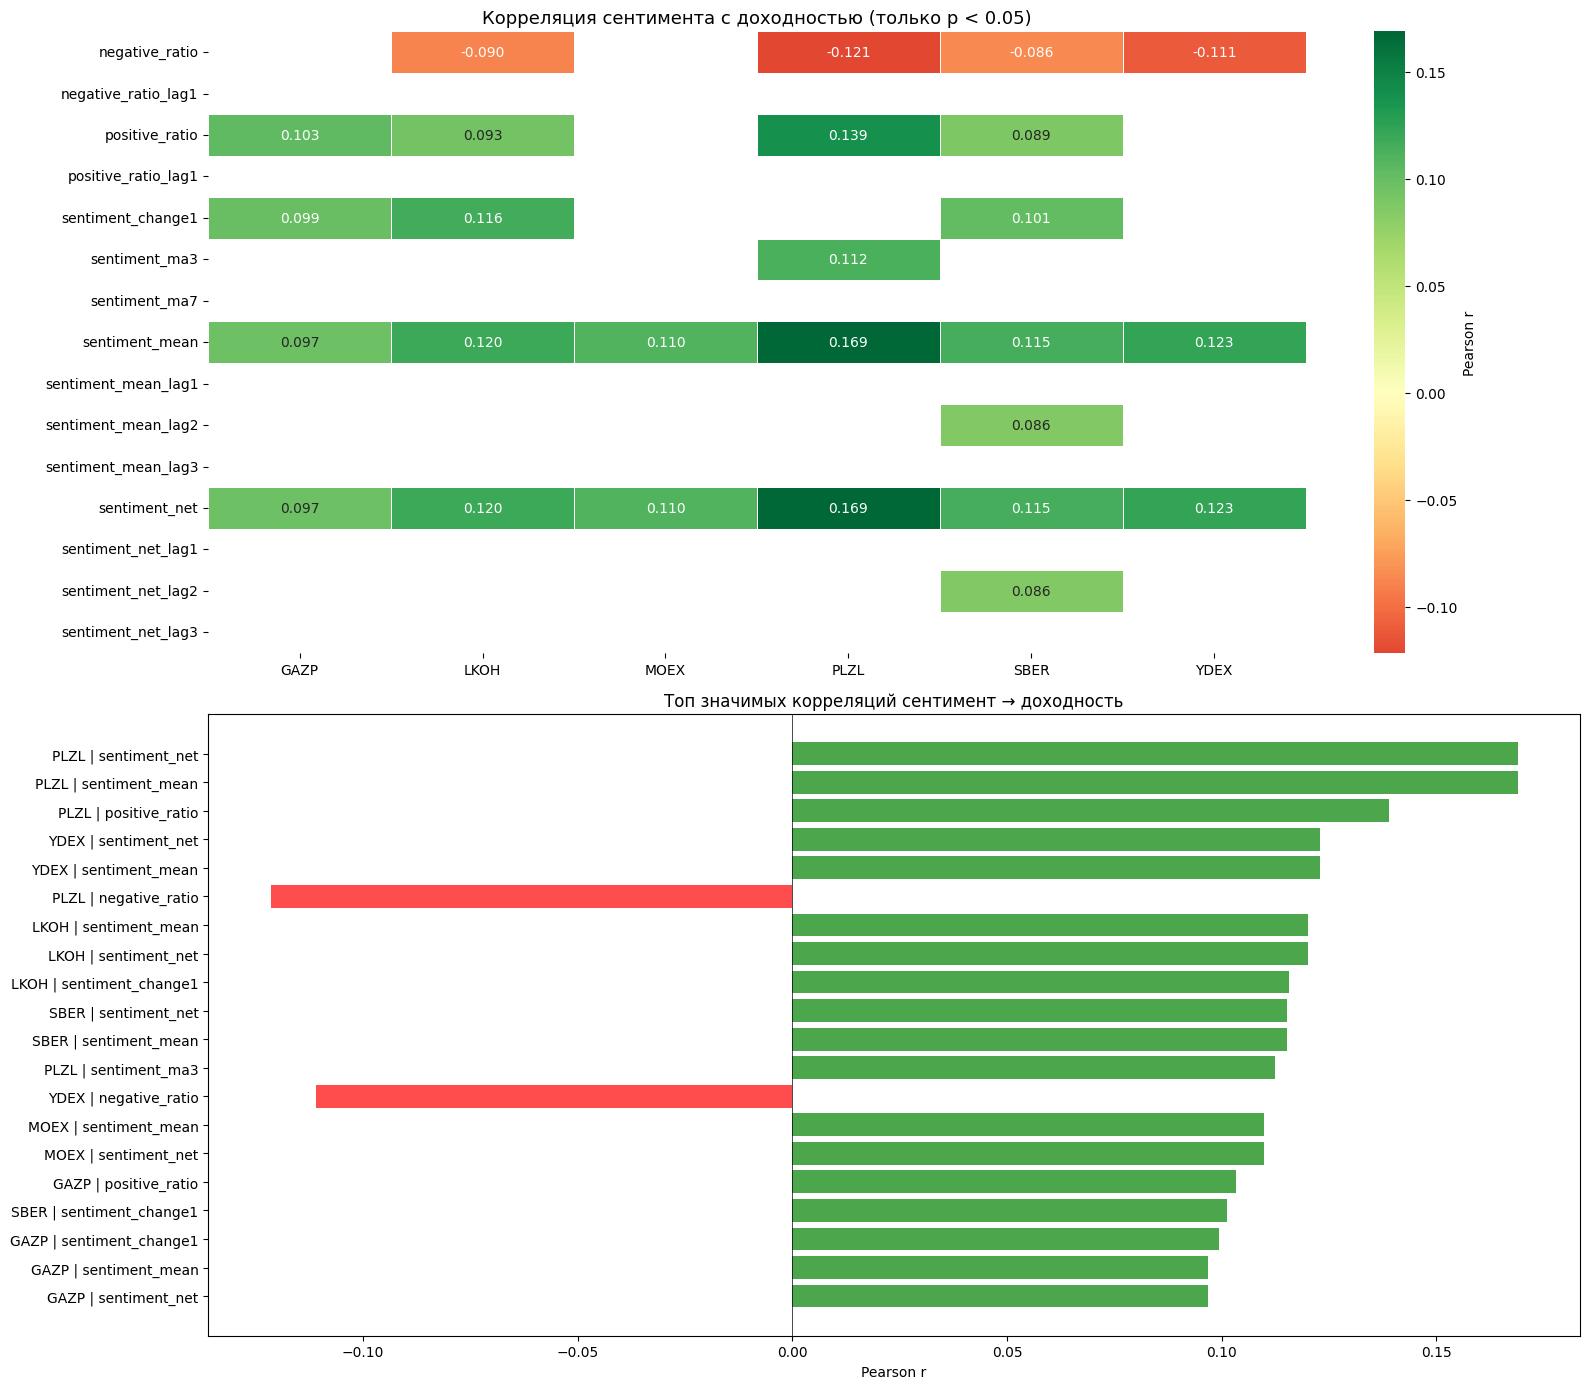

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# График 1 — тепловая карта корреляций по тикерам
pivot_pearson = df_corr.pivot(index='feature', columns='ticker', values='pearson_r')
pivot_pval    = df_corr.pivot(index='feature', columns='ticker', values='pearson_p')

# Маска для незначимых
mask = pivot_pval >= 0.05

sns.heatmap(
    pivot_pearson,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)
axes[0].set_title('Корреляция сентимента с доходностью (только p < 0.05)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# График 2 — топ корреляций по абсолютному значению
top_corr = df_corr[df_corr['significant']].copy()
top_corr['abs_r'] = top_corr['pearson_r'].abs()
top_corr = top_corr.sort_values('abs_r', ascending=True).tail(20)
top_corr['label'] = top_corr['ticker'] + ' | ' + top_corr['feature']

colors = ['green' if r > 0 else 'red' for r in top_corr['pearson_r']]
axes[1].barh(top_corr['label'], top_corr['pearson_r'], color=colors, alpha=0.7)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Топ значимых корреляций сентимент → доходность')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/sentiment_correlation.png', dpi=150)
plt.show()

In [4]:
from statsmodels.tsa.stattools import grangercausalitytests

print('=== ТЕСТ ГРЕЙНДЖЕРА: сентимент → доходность ===')
print('H0: сентимент НЕ помогает предсказывать доходность')
print('Если p < 0.05 — отвергаем H0, сентимент влияет на доходность\n')

granger_results = []

for ticker, df in datasets.items():
    # Берём две переменные: доходность и сентимент
    data = df[['return_1d', 'sentiment_mean']].dropna()

    try:
        # Проверяем лаги 1, 2, 3
        test = grangercausalitytests(data, maxlag=3, verbose=False)

        for lag in [1, 2, 3]:
            p_value = test[lag][0]['ssr_ftest'][1]
            granger_results.append({
                'ticker': ticker,
                'lag': lag,
                'p_value': p_value,
                'significant': p_value < 0.05
            })
            sig = '✅ значимо' if p_value < 0.05 else '❌ не значимо'
            print(f'{ticker} lag={lag}: p={p_value:.4f} {sig}')
    except Exception as e:
        print(f'{ticker}: ошибка — {e}')
    print()

df_granger = pd.DataFrame(granger_results)
print(f'Значимых результатов: {df_granger["significant"].sum()} из {len(df_granger)}')

=== ТЕСТ ГРЕЙНДЖЕРА: сентимент → доходность ===
H0: сентимент НЕ помогает предсказывать доходность
Если p < 0.05 — отвергаем H0, сентимент влияет на доходность

MOEX lag=1: p=0.8022 ❌ не значимо
MOEX lag=2: p=0.7241 ❌ не значимо
MOEX lag=3: p=0.9089 ❌ не значимо

SBER lag=1: p=0.7048 ❌ не значимо
SBER lag=2: p=0.7909 ❌ не значимо
SBER lag=3: p=0.9280 ❌ не значимо

GAZP lag=1: p=0.3269 ❌ не значимо
GAZP lag=2: p=0.5076 ❌ не значимо
GAZP lag=3: p=0.2013 ❌ не значимо

LKOH lag=1: p=0.5310 ❌ не значимо
LKOH lag=2: p=0.5976 ❌ не значимо
LKOH lag=3: p=0.8132 ❌ не значимо

PLZL lag=1: p=0.7423 ❌ не значимо
PLZL lag=2: p=0.2076 ❌ не значимо
PLZL lag=3: p=0.5498 ❌ не значимо

YDEX lag=1: p=0.7884 ❌ не значимо
YDEX lag=2: p=0.3980 ❌ не значимо
YDEX lag=3: p=0.7157 ❌ не значимо

Значимых результатов: 0 из 18


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

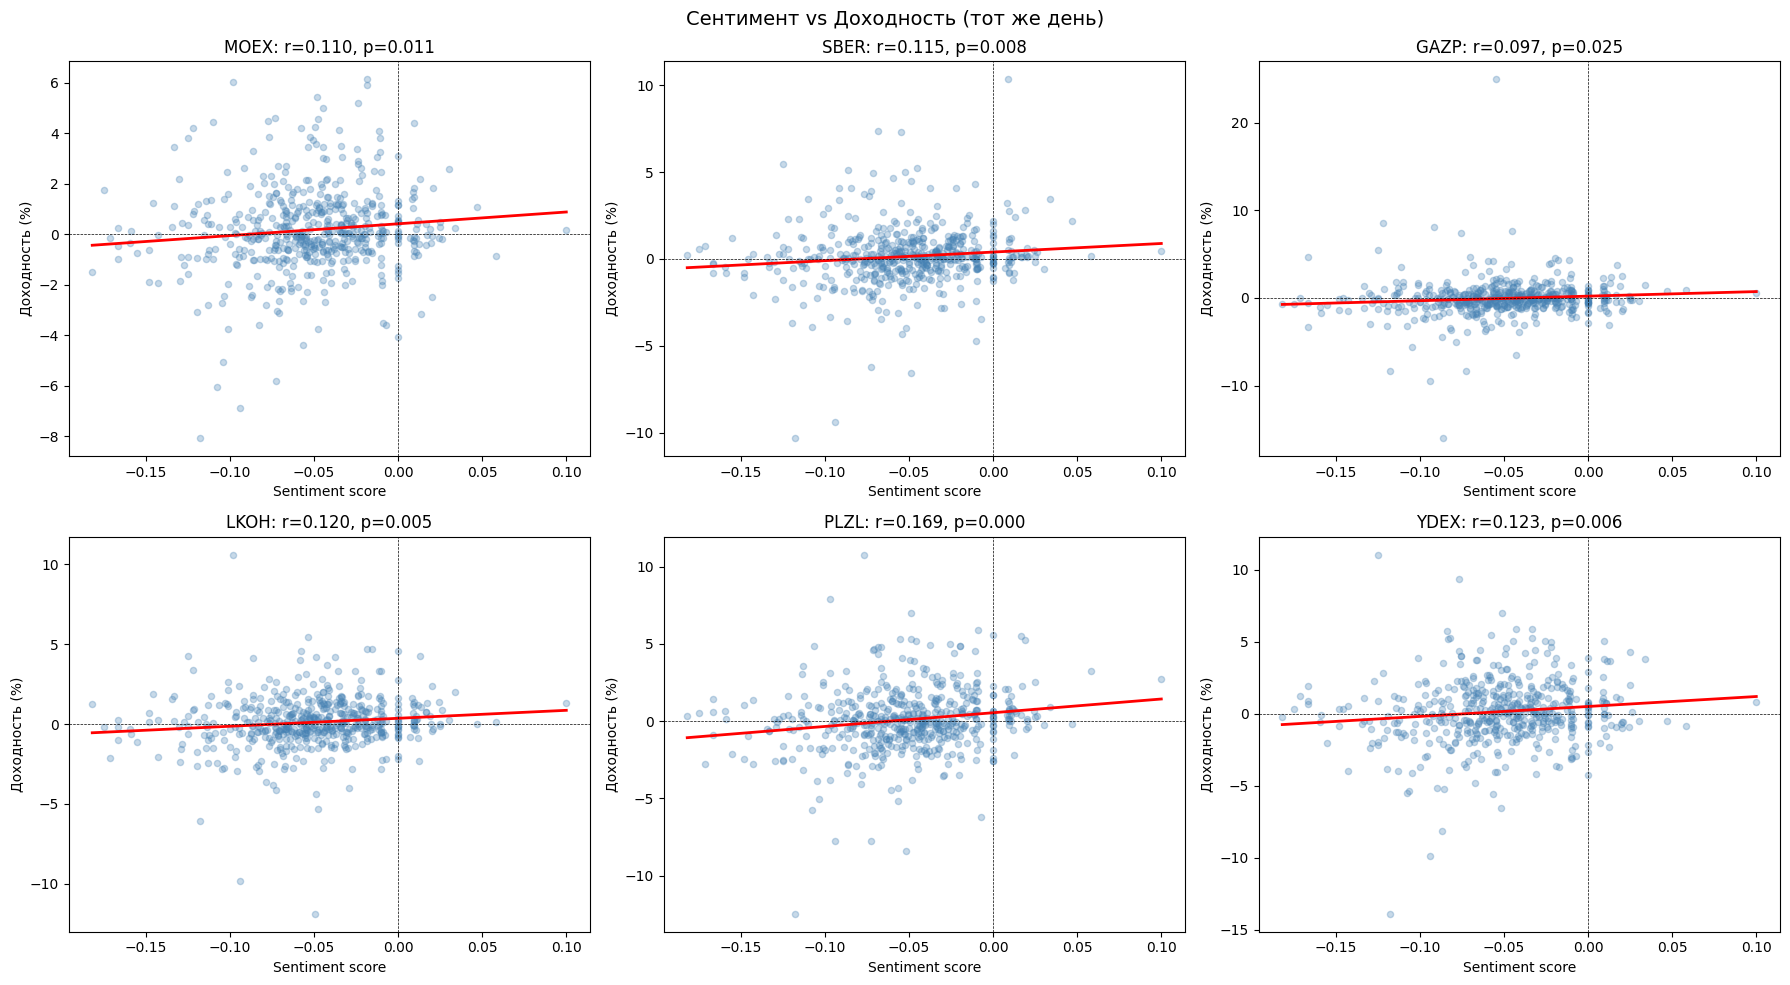

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df = datasets[ticker]
    ax = axes[i]

    # Scatter plot
    ax.scatter(df['sentiment_mean'], df['return_1d'],
               alpha=0.3, color='steelblue', s=20)

    # Линия тренда
    z = np.polyfit(df['sentiment_mean'], df['return_1d'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['sentiment_mean'].min(), df['sentiment_mean'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2)

    # Корреляция
    r, pval = stats.pearsonr(df['sentiment_mean'], df['return_1d'])
    ax.set_title(f'{ticker}: r={r:.3f}, p={pval:.3f}')
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Доходность (%)')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Сентимент vs Доходность (тот же день)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/sentiment_vs_return_scatter.png', dpi=150)
plt.show()

In [6]:
print('=== ИТОГ НОУТБУКА 05: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===')
print()
print('Гипотеза: тональность финансовых новостей связана с доходностью акций')
print()
print('--- РЕЗУЛЬТАТЫ ---')
print()
print('1. Корреляция Pearson (сентимент vs доходность того же дня):')
for ticker in TICKERS:
    df = datasets[ticker]
    r, p = stats.pearsonr(df['sentiment_mean'], df['return_1d'])
    sig = '✅' if p < 0.05 else '❌'
    print(f'   {sig} {ticker}: r={r:.3f}, p={p:.3f}')

print()
print('2. Тест Грейнджера (сентимент lag1-3 → доходность):')
print('   ❌ Все тикеры: p > 0.05 — причинность не подтверждена')
print()
print('--- ИНТЕРПРЕТАЦИЯ ---')
print('+ Сентимент статистически значимо коррелирует с доходностью того же дня')
print('+ Сильнее всего: PLZL (r=0.169), YDEX (r=0.123), LKOH (r=0.120)')
print('+ Слабее всего:  GAZP (r=0.097) — специфика газового сектора')
print('- Предсказательной силы с задержкой нет — рынок быстро отыгрывает новости')
print()
print('Следующий шаг: построение моделей прогнозирования → ноутбук 06')

=== ИТОГ НОУТБУКА 05: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===

Гипотеза: тональность финансовых новостей связана с доходностью акций

--- РЕЗУЛЬТАТЫ ---

1. Корреляция Pearson (сентимент vs доходность того же дня):
   ✅ MOEX: r=0.110, p=0.011
   ✅ SBER: r=0.115, p=0.008
   ✅ GAZP: r=0.097, p=0.025
   ✅ LKOH: r=0.120, p=0.005
   ✅ PLZL: r=0.169, p=0.000
   ✅ YDEX: r=0.123, p=0.006

2. Тест Грейнджера (сентимент lag1-3 → доходность):
   ❌ Все тикеры: p > 0.05 — причинность не подтверждена

--- ИНТЕРПРЕТАЦИЯ ---
+ Сентимент статистически значимо коррелирует с доходностью того же дня
+ Сильнее всего: PLZL (r=0.169), YDEX (r=0.123), LKOH (r=0.120)
+ Слабее всего:  GAZP (r=0.097) — специфика газового сектора
- Предсказательной силы с задержкой нет — рынок быстро отыгрывает новости

Следующий шаг: построение моделей прогнозирования → ноутбук 06
